In [ ]:
#Code file 3

In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import geopandas as gpd
import earthpy as et
import xarray as xr
# Spatial subsetting of netcdf files
import regionmask
import rioxarray


import pyproj
from shapely.ops import transform
from shapely.geometry import Point
import glob
from csv import writer


# Plotting options
sns.set(font_scale=1.3)
sns.set_style("white")


import warnings
warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API.*",
    category=UserWarning
)

import earthpy as et

#To import from other notebooks, install ipynb
# import ipynb
# from ipynb.fs.defs.all_data_for_location import get_location_data_all_pixels

/mnt/home/f0113797/.conda/envs/testgeo4/lib/python3.14/site-packages/earthpy/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_string


In [3]:
#CHANGED THE COORDINATES CALCULATIONS

def convert_longitude(ds):
    ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180))
    ds = ds.sortby('lon')
    return ds

def get_location_data_all_pixels(input_path, projection, *, target_lat = None, target_lon = None, shapefile = None, buffer = None):
    climate_scenario = ["ARISE_SAI_1p0", "ARISE_SAI_1p5", "SSP245"]
    climate_variables = ["SSP", "TSMX", "PRECT"]
    
    info_list = {}

    list_of_files = glob.glob(input_path + '/*.nc') 
    file_reprojected = []
    
    for each in list_of_files:
        file = xr.open_dataset(each)
        file = convert_longitude(file)
        file = file.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
        file.rio.write_crs("EPSG:4326", inplace=True) #Set our reference system (mercator projection)
        file = file.rio.reproject(projection)
        file_reprojected.append(file)
        
    
    if (target_lat != None and target_lon != None and shapefile == None):
        point = Point(target_lon, target_lat)
        gdf_point = gpd.GeoDataFrame(geometry=[point], crs="EPSG:4326")
        gdf_projected = gdf_point.to_crs(projection) #CONUS coordinate.
        
        
        masked_files_list = []        
        if (buffer != None):          #Buffered point
            buffered_geom = gdf_projected.geometry.buffer(buffer) #apply buffer.
            for each in file_reprojected:  
                masked_data = each.rio.clip(buffered_geom.geometry, drop = True, all_touched=True) #Set true if you want to crop it. 
                masked_files_list.append(masked_data)
                
            return masked_files_list
            
        
        else:           #No buffer point
            for each in file_reprojected:
                point_data = each.rio.clip(gdf_projected.geometry, drop = True, all_touched=True)
                #point_data = file_reprojected.sel(lat=target_lat, lon=target_lon, method='nearest')
                masked_files_list.append(point_data)
            return masked_files_list
                    
    elif (target_lat == None and target_lon == None):  #Shapefile        
        
        masked_files_list = []        
        for each in file_reprojected:            
            mask = shapefile.to_crs(each.rio.crs)
            sliced_masked = each.rio.clip(
                mask.geometry,
                mask.crs,
                drop=True,
                all_touched=True
            )
            
            masked_files_list.append(sliced_masked)
        return masked_files_list

    else: 
        return("Please enter either a point or a shapefile correctly.")
    #Checking for correct inputs. 

In [4]:
#Using new long coordinates
mask_path = "/mnt/research/nasabio/data/neon_domains/NEON_Domains.shp"
NEON_sites = gpd.read_file(mask_path)
south_plains = NEON_sites[NEON_sites.domainName == "Southern Plains"]

sp = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/future", "EPSG:5070", shapefile = south_plains)

In [5]:
#Using new long coordinates
mask_path = "/mnt/research/nasabio/data/neon_domains/NEON_Domains.shp"
NEON_sites = gpd.read_file(mask_path)

south_plains = NEON_sites[NEON_sites.domainName == "Southern Plains"]
sp_p = get_location_data_all_pixels("/mnt/research/nasabio/data/climate/L1/present", "EPSG:5070", shapefile = south_plains)

[-103.71677283 -102.60211481 -101.48745678 -100.37279876  -99.25814073
  -98.14348271  -97.02882468  -95.91416665  -94.79950863  -93.6848506
  -92.57019258]
[37.90553813 36.7908801  35.67622208 34.56156405 33.44690603 32.332248
 31.21758998 30.10293195 28.98827393 27.8736159  26.75895787 25.64429985]


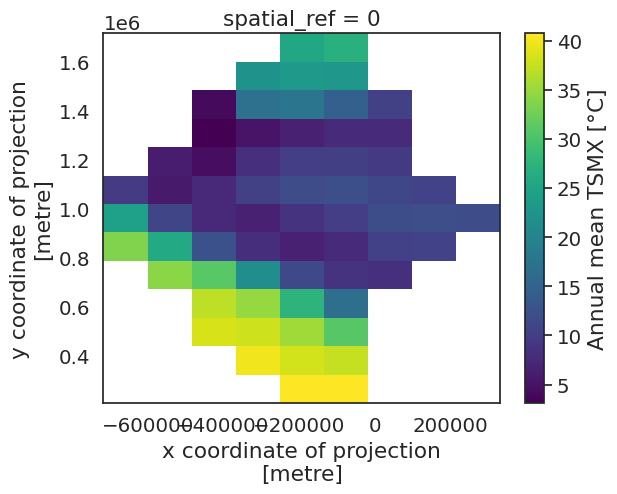

In [53]:
#This was mapped using OLD longitutde coordinate switch. 
sp_p[0]["annual_mean"].plot()
sp_ll = sp_p[0].rio.reproject("EPSG:4326")
print(sp_ll.x.values)  # longitude
print(sp_ll.y.values)  # latitude

[-103.71677283 -102.60211481 -101.48745678 -100.37279876  -99.25814073
  -98.14348271  -97.02882468  -95.91416665  -94.79950863  -93.6848506
  -92.57019258]
[37.90553813 36.7908801  35.67622208 34.56156405 33.44690603 32.332248
 31.21758998 30.10293195 28.98827393 27.8736159  26.75895787 25.64429985]


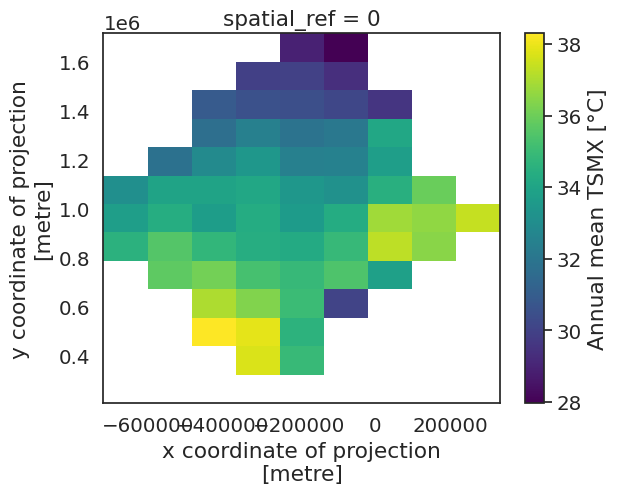

In [79]:
#This was mapped using NEW CHANGED longitutde coordinate switch. Seems more correct for Texas, temperatures are not like 3 degrees T_T
sp_p[0]["annual_mean"].plot()
sp_ll = sp_p[0].rio.reproject("EPSG:4326")
print(sp_ll.x.values)  # longitude
print(sp_ll.y.values)  # latitude

23.164306640625 38.550682067871094


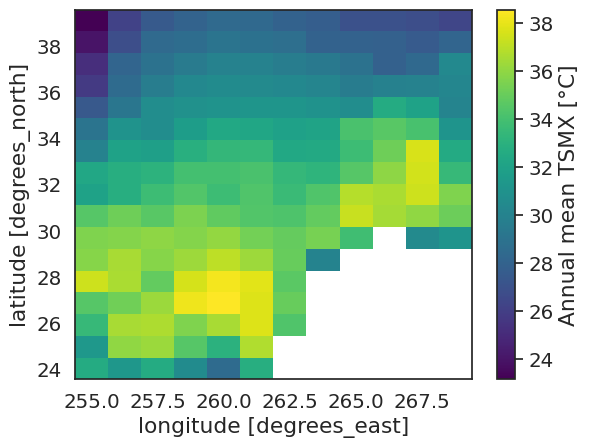

In [47]:
#This is approximatly the region of the Southern plains. Seems about correct!

x2 = test["annual_mean"].sel(
    lat=slice(24, 39.5),
    lon=slice(255, 269)
)

print(float(x2.min()), float(x2.max()))
x2.plot()

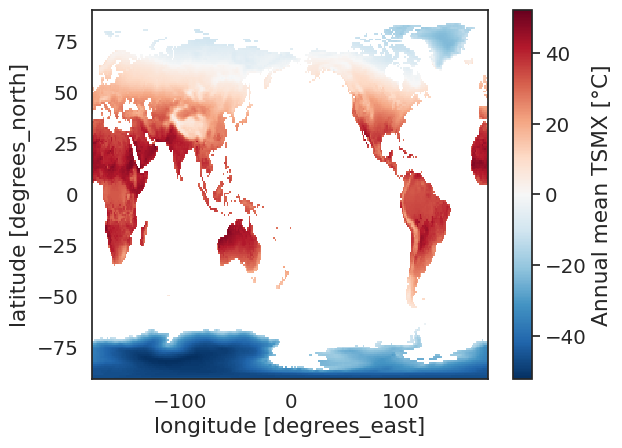

In [74]:
def convert_longitude(ds):
    ds = ds.assign_coords(lon=(ds.lon % 360 - 180))
    ds = ds.sortby('lon')
    return ds
y = convert_longitude(test)
y1 = y["annual_mean"].sel(lat=slice(25, 50), lon=slice(-103, -92))
y["annual_mean"].plot()

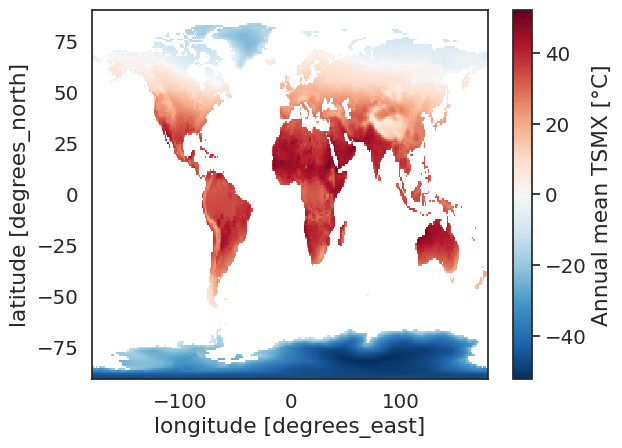

In [75]:
def convert_longitude(ds):
    ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180))
    ds = ds.sortby('lon')
    return ds
y = convert_longitude(test)
y1 = y["annual_mean"].sel(lat=slice(24, 39.5), lon=slice(-103, -92))
y["annual_mean"].plot()

In [114]:
list(sp_p[0].data_vars)

['annual_mean', 'frequency', 'duration', 'mean_intensity', 'max_intensity']

<xarray.Dataset> Size: 3kB
Dimensions:         (x: 9, y: 13)
Coordinates:
  * x               (x) float64 72B -6.587e+05 -5.421e+05 ... 1.574e+05 2.74e+05
  * y               (y) float64 104B 1.657e+06 1.541e+06 ... 3.81e+05 2.65e+05
    spatial_ref     int64 8B 0
Data variables:
    annual_mean     (y, x) float32 468B nan nan nan nan ... nan nan nan nan
    frequency       (y, x) float64 936B nan nan nan nan 3.82 ... nan nan nan nan
    duration        (y, x) float64 936B nan nan nan nan ... nan nan nan nan
    mean_intensity  (y, x) float32 468B nan nan nan nan ... nan nan nan nan
    max_intensity   (y, x) float32 468B nan nan nan nan ... nan nan nan nan
Attributes:
    scenario:               SSP245
    variable:               TSMX
    member:                 006
    event_type:             extreme_high
    season:                 annual
    clim_reference:         SSP245 TSMX 2015-2034
    consec_days_threshold:  3
    extreme_direction:      above
    quantile:               0.9


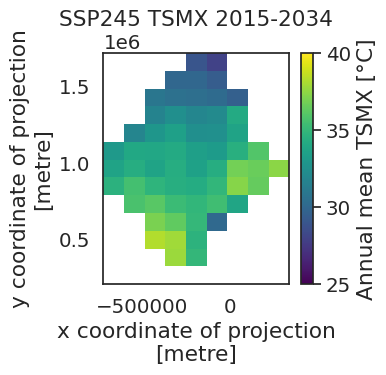

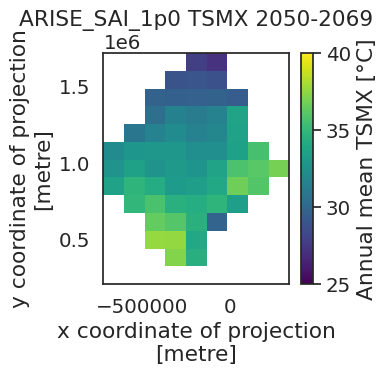

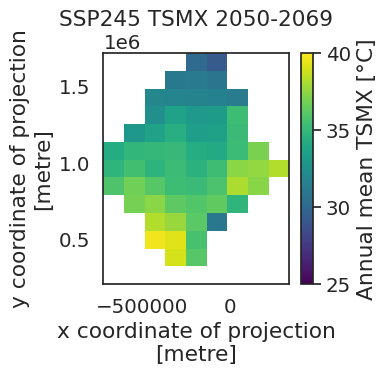

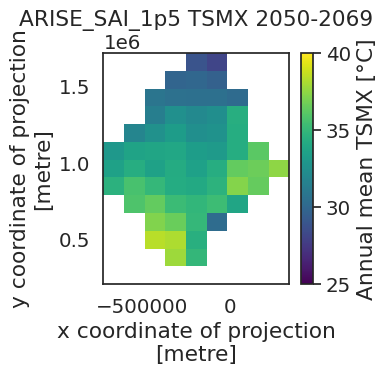

In [6]:
sp_tsmx = [sp_p[0], sp[0], sp[1], sp[6]]

data_vars = list(sp_tsmx[0].data_vars)
#You can choose a data_variable, I am not graphing all of these for every scenario. >:(
var = "annual_mean"

comparison_dict = {
    "all_max" : -50, 
    "all_min" : 50
}



for scenario in sp_tsmx: 
    comp_list = [mean, range, max, min] #within each scenario, comapre the grids with itself 
    if (float(scenario[str(var)].max()) > comparison_dict["all_max"]): 
        comparison_dict["all_max"] = float(scenario[str(var)].max())
    if (float(scenario[str(var)].min()) < comparison_dict["all_min"]): 
        comparison_dict["all_min"] = float(scenario[str(var)].min())
    comparison_dict[scenario.clim_reference] = comp_list

print(comparison_dict)

for each in sp_tsmx: 
    plt.figure(figsize = (3,3)) 
    each[var].plot(vmin = 25, vmax = 40)
    plt.title(each.clim_reference)
plt.show()


In [ ]:
#from all_data_for_location.ipynb import get_location_data_all_pixels
from ipynb.fs.full.all_data_for_location import get_location_data_all_pixels

path_present = "/mnt/research/nasabio/data/climate/L1/present/SSP245_TSMX_extreme_high.nc"
path_SAI10 = "/mnt/research/nasabio/data/climate/L1/future/ARISE_SAI_1p0_TSMX_extreme_high.nc"
path_SAI15 = "/mnt/research/nasabio/data/climate/L1/future/ARISE_SAI_1p5_TSMX_extreme_high.nc"
path_SSP245 = "/mnt/research/nasabio/data/climate/L1/future/SSP245_TSMX_extreme_high.nc"

def compare_scenarios_avg(climate_variable_title, path_file, *, shapefile = None, target_lat = None, target_lon = None, buffer = None):
    scenarios = ["ARISE_SAI_1p0_", "ARISE_SAI_1p5_", "SSP245_"]
    avg_datasets = {}
    for each in scenarios: 
        avg_dataset = xr.open_dataset(path_file + "/" + each + "_" + climate_variable_title + ".nc")



for each in temp_netcdf:
    mean_of_var = np.nanmean(each["annual_mean"].values)
    print(mean_of_var)
    
    plt.figure(figsize = (7,5))
    each["annual_mean"].plot()
    plt.show()
    

In [ ]:
from ipynb.fs.full.all_data_for_location import get_location_data_all_pixels


In [ ]:
path_SAI10 = "/mnt/research/nasabio/data/climate/L1/future/ARISE_SAI_1p0_TSMX_extreme_high.nc"
path_SAI15 = "/mnt/research/nasabio/data/climate/L1/future/ARISE_SAI_1p5_TSMX_extreme_high.nc"
path_SSP245 = "/mnt/research/nasabio/data/climate/L1/future/SSP245_TSMX_extreme_high.nc"

temp_netcdf = [xr.open_dataset(path_SAI10), xr.open_dataset(path_SAI15), xr.open_dataset(path_SSP245)]


mask_path = "/mnt/research/nasabio/data/neon_domains/NEON_Domains.shp"
NEON_sites = gpd.read_file(mask_path)
mid_atl = NEON_sites[NEON_sites.domainName == "Mid Atlantic"]


for each in temp_netcdf:
    mask = regionmask.mask_geopandas(mid_atl, each.lon, each.lat)
    sliced_masked = each.where(mask.notnull(), drop=True)

    mean_of_var = np.nanmean(each["annual_mean"].values)
    print(mean_of_var)
    
    plt.figure(figsize = (7,5))

    sliced_masked["annual_mean"].plot(vmin = 20, vmax = 31)
    plt.show()